# TripAdvisor User Ratings Clustering Analysis
Since the TripAdvisor dataset contains numerical ratings across 10 categories (and no actual text reviews), we will apply K-Means Clustering and Principal Component Analysis (PCA) to discover user segmentation patterns.

## 1. Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')


## 2. Load and Inspect Data

In [2]:
df = pd.read_csv('tripadvisor_review.csv')
display(df.head())
print("Dataset Shape:", df.shape)


,User ID,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,User 3,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,User 4,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,User 5,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


Dataset Shape: (980, 11)


## 3. Data Preprocessing

In [3]:
# Drop the 'User ID' as it is non-informative for clustering
X_original = df.drop('User ID', axis=1)

# Feature Scaling is crucial for K-Means Since ratings could have different variances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

# Keep scaled data in dataframe for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X_original.columns)
display(X_scaled_df.head())


,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10
0,0.112645,0.935887,1.619750,0.312960,-0.319608,1.070169,1.158657,-0.327872,0.687518,-1.180591
1,0.388088,1.772644,2.089171,0.384494,1.098486,2.479500,3.716053,-1.492056,0.797274,-1.491908
2,1.000186,-1.156005,-0.600487,-0.008942,-1.600466,-0.561689,-0.120041,-0.255111,-0.711877,-0.931537
3,-1.356389,0.935887,-0.917663,0.134126,-1.097272,-0.598777,-0.120041,0.909073,0.001540,0.189205
4,-1.172760,-0.319248,0.211486,0.134126,1.372955,0.328415,-0.120041,-0.400634,-1.068585,-0.807010


## 4. Find optimal number of clusters (Elbow Method)

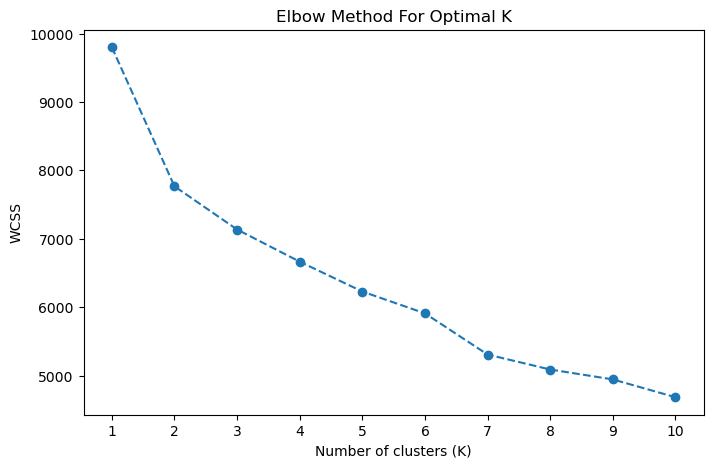

The 'Elbow' typically appears where the bend is sharpest (e.g., K=3 or K=4).


In [4]:
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.show()

print("The 'Elbow' typically appears where the bend is sharpest (e.g., K=3 or K=4).")


## 5. Build Final K-Means Model (k=3)

In [5]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original df
df['Cluster'] = clusters
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score for k=3:", round(score, 3))


Silhouette Score for k=3: 0.131


## 6. Dimensionality Reduction & Visualization with PCA

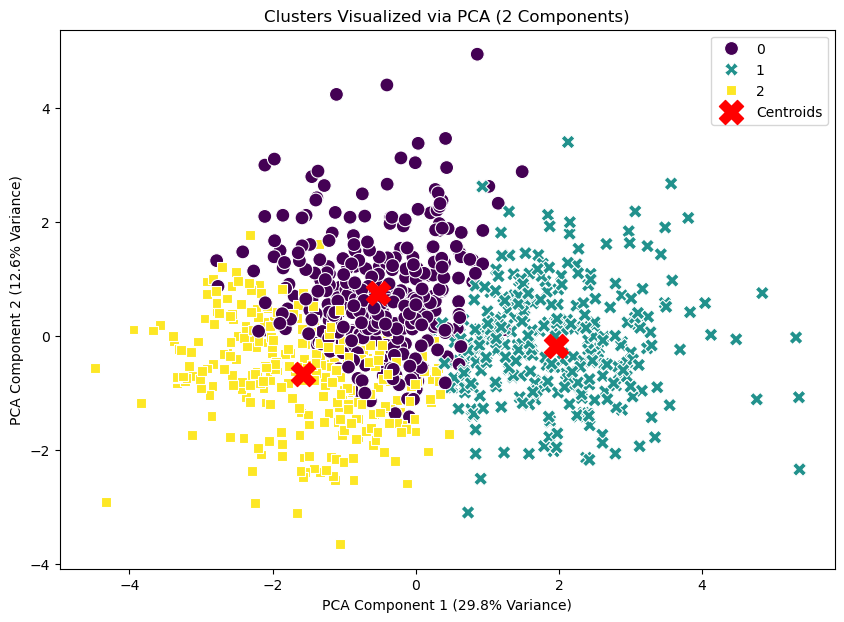

In [6]:
# Reduce 10 categories to 2 Dimensions for 2D Plotting
pca = PCA(n_components=2)
reduced_X = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_X[:, 0], y=reduced_X[:, 1], hue=clusters, palette='viridis', style=clusters, s=100)

# Plotting the centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('Clusters Visualized via PCA (2 Components)')
plt.xlabel(f'PCA Component 1 ({round(pca.explained_variance_ratio_[0]*100, 1)}% Variance)')
plt.ylabel(f'PCA Component 2 ({round(pca.explained_variance_ratio_[1]*100, 1)}% Variance)')
plt.legend()
plt.show()


## 7. Analyze Clusters

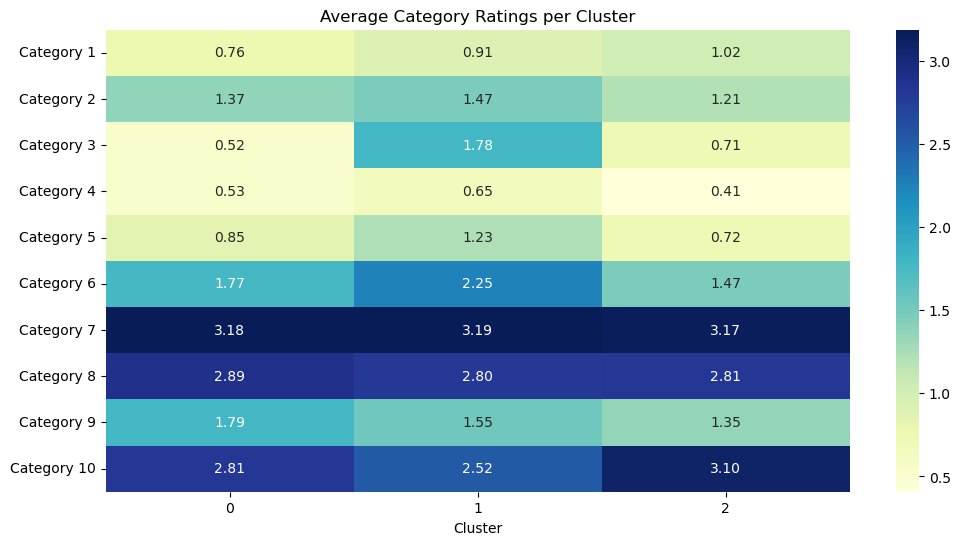

In [7]:
# Calculate the average rating per category for each cluster to understand user segments
cluster_means = df.drop('User ID', axis=1).groupby('Cluster').mean()
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Average Category Ratings per Cluster")
plt.show()
